# NB05 — Tier-A Scoring Pipeline

**Project**: `ibd_phage_targeting` — Pillar 2 close-out
**Depends on**: NB04c (within-substudy meta), NB04e (ecotype-specific Tier-A), NB04h (HMP2 external replication), and the CrohnsPhage mart reference tables (BGC catalog, Kumbhari strain-adaptation, species-IBD associations, phage biology curation).

## Purpose

NB04d and NB04e produced the rigor-controlled input candidate set. NB05 applies the Tier-A criteria A3 – A6 from `RESEARCH_PLAN.md` to produce a scored + ranked target list for Pillar 4 (phage targetability) and Pillar 5 (per-patient cocktails).

## Criteria

| Criterion | Source | Scoring |
|---|---|---|
| A3 Literature + cohort CD-association | NB04c meta + HMP2 replication + `ref_cd_vs_hc_differential` + `ref_species_ibd_associations` + `ref_phage_biology` | 0–5 |
| A4 Protective-analog exclusion | NB04c within-substudy sign + curated protective-species list | 0 or 1 |
| A5 Engraftment / strain adaptation | Donor 2708 + `fact_strain_competition` + Kumbhari gene-strain | 0 / 0.5 / 1 |
| A6 BGC inflammatory mediator | `ref_bgc_catalog` + `ref_cborf_enrichment` | 0 / 0.5 / 1 |

## Execution note

This notebook was run via `run_nb05.py` (standalone script) rather than nbconvert
because of an environment-specific numpy.bool serialization issue in the
nbconvert notebook-save path. Outputs are authoritative and written to
`data/nb05_tier_a_scored.tsv`, `data/nb05_tier_a_verdict.json`, and
`figures/NB05_tier_a_scored.png`.


In [1]:
# Imports and constants (see run_nb05.py for full execution)
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
DATA_MART = Path.home() / 'data' / 'CrohnsPhage'
DATA_OUT = Path('../data'); FIG_OUT = Path('../figures')

PROTECTIVE_REFERENCE = {
    'Faecalibacterium prausnitzii', 'Akkermansia muciniphila',
    'Roseburia intestinalis', 'Roseburia hominis', 'Lachnospira eligens',
    'Agathobacter rectalis', 'Clostridium scindens', 'Coprococcus eutactus',
    'Bifidobacterium adolescentis', 'Bifidobacterium longum',
}
ENGRAFTED = ['Mediterraneibacter gnavus', 'Eggerthella lenta', 'Escherichia coli',
             'Enterocloster bolteae', 'Hungatella hathewayi', 'Klebsiella oxytoca']


## §1. Build candidate set

In [2]:
# See run_nb05.py for full source. Loads NB04e E1 + E3 Tier-A and NB04c engraftment candidates.
# Dedups to unique species with multi-category ecotype_membership string.

E1 Tier-A: 51; E3 provisional Tier-A: 40
Engraftment-confirmed cross-ecotype: 5

Unique candidates: 71
ecotype_membership
E1                                             27
E3_provisional                                 20
E1|E3_provisional                              19
E1|cross_ecotype_engraftment                    4
E1|E3_provisional|cross_ecotype_engraftment     1


## §2. Invert synonymy layer (canonical → aliases)

In [3]:
# Required because ref_bgc_catalog, ref_cd_vs_hc_differential etc. use pre-GTDB-r214 names.

  Mediterraneibacter gnavus
    Mediterraneibacter gnavus
    Ruminococcus gnavus
    [Ruminococcus] gnavus
  Enterocloster bolteae
    Clostridium bolteae
    Enterocloster bolteae
  Erysipelatoclostridium innocuum
    Clostridium innocuum
    Erysipelatoclostridium innocuum
    Faecalibacillus faecis
    [Clostridium] innocuum
  Hungatella symbiosa
    Clostridium symbiosum
    Hungatella symbiosa
    Otoolea symbiosa
    [Clostridium] symbiosum


## §3. A3 — Literature + cohort CD-association scoring

Five independent signals (each 0 or 1): NB04c confound-free meta, HMP2 external replication concordance, `ref_cd_vs_hc_differential` (log2FC > 0.5 + FDR < 0.10), `ref_species_ibd_associations` (dxIBD coefficient > 0 + p < 0.05), `ref_phage_biology` curated target flag.

In [4]:
# A3 = sum of the 5 signals

A3 score distribution:
a3_score
0    13
1    22
2    25
3     5
4     5
5     1


## §4. A4 — Protective-analog exclusion

Binary gate: pass (1) unless the candidate has a negative within-IBD-substudy CD-vs-nonIBD effect (confound-free protective-analog signal) OR sits on the curated protective-species list.

In [5]:
# A4 = 0 (protective-analog risk) or 1 (pass)

A4 score distribution:
a4_score
0     3
1    68

Candidates failing A4:
             species                                                             a4_note
 Anaerostipes hadrus      confound-free effect negative (-0.32) - protective-analog risk
Clostridium scindens on curated protective-species list - strain-level scrutiny required
    Roseburia faecis      confound-free effect negative (-2.74) - protective-analog risk


## §5. A5 — Engraftment / strain adaptation

Three evidence tiers: direct donor 2708 engraftment (1.0), Kumbhari strain-competition disease-dominance (0.5), Kumbhari IBD-adapted-strain gene signal (0.5).

In [6]:
# A5 = 0.0 / 0.5 / 1.0

A5 score distribution:
a5_score
0.0    63
0.5     3
1.0     5

A5 = 1.0 direct engraftment:
                  species                          a5_note
        Eggerthella lenta donor 2708 engraftment-confirmed
    Enterocloster bolteae donor 2708 engraftment-confirmed
         Escherichia coli donor 2708 engraftment-confirmed
     Hungatella hathewayi donor 2708 engraftment-confirmed
Mediterraneibacter gnavus donor 2708 engraftment-confirmed

A5 = 0.5 (strain-level signal, top 10):
                     species                                       a5_note
         Anaerostipes hadrus Kumbhari strain-competition disease-dominance
Bacteroides cellulosilyticus Kumbhari strain-competition disease-dominance
      Flavonifractor plautii Kumbhari strain-competition disease-dominance


## §6. A6 — BGC inflammatory mediator

For each candidate, look up BGCs in `ref_bgc_catalog` (via synonymy-inverted matching), count total BGCs and those containing CD-enriched CB-ORFs (from `ref_cborf_enrichment`, effect > 0.5 + FDR < 0.05). Report MIBiG-matched compound names where available (e.g., *E. coli* → Colibactin, Yersiniabactin, Enterobactin).

In [7]:
# A6 = 0.0 (no BGC), 0.5 (BGC but no CD-enriched), 1.0 (BGC with CD-enriched CB-ORFs)

BGCs with CD-enriched CB-ORFs: 283

A6 score distribution:
a6_score
0.0    27
0.5    30
1.0    14

A6 = 1.0 (BGC + CD-enriched CB-ORFs, top 15):
                       species                                                                                    a6_note
              Actinomyces oris                                               11 BGCs, 2 CD-enriched CB-ORFs (MIBiG: none)
             Blautia coccoides                                               13 BGCs, 1 CD-enriched CB-ORFs (MIBiG: none)
  Enterocloster asparagiformis                                                4 BGCs, 2 CD-enriched CB-ORFs (MIBiG: none)
       Enterocloster citroniae                                                1 BGCs, 1 CD-enriched CB-ORFs (MIBiG: none)
Enterocloster clostridioformis                                               11 BGCs, 2 CD-enriched CB-ORFs (MIBiG: none)
              Escherichia coli   93 BGCs, 2 CD-enriched CB-ORFs (MIBiG: ['Colibactin', 'Yersiniabactin', 'Enterobactin'])
 

## §7. Aggregate + rank

In [8]:
# Total Tier-A = A3/5 + A4 + A5 + A6 (0-4 range); actionable threshold = 2.5

Total candidates scored: 71
Actionable (total_score >= 2.5): 6

TOP 20:
 rank                        species                          ecotype_membership  a3_score  a4_score  a5_score  a6_score  total_score  actionable
    1           Hungatella hathewayi                E1|cross_ecotype_engraftment         5         1       1.0       1.0          4.0        True
    2      Mediterraneibacter gnavus E1|E3_provisional|cross_ecotype_engraftment         4         1       1.0       1.0          3.8        True
    3               Escherichia coli                E1|cross_ecotype_engraftment         3         1       1.0       1.0          3.6        True
    4              Eggerthella lenta                E1|cross_ecotype_engraftment         4         1       1.0       0.5          3.3        True
    5         Flavonifractor plautii                           E1|E3_provisional         4         1       0.5       1.0          3.3        True
    6          Enterocloster bolteae                

## §8. Scoring matrix heatmap

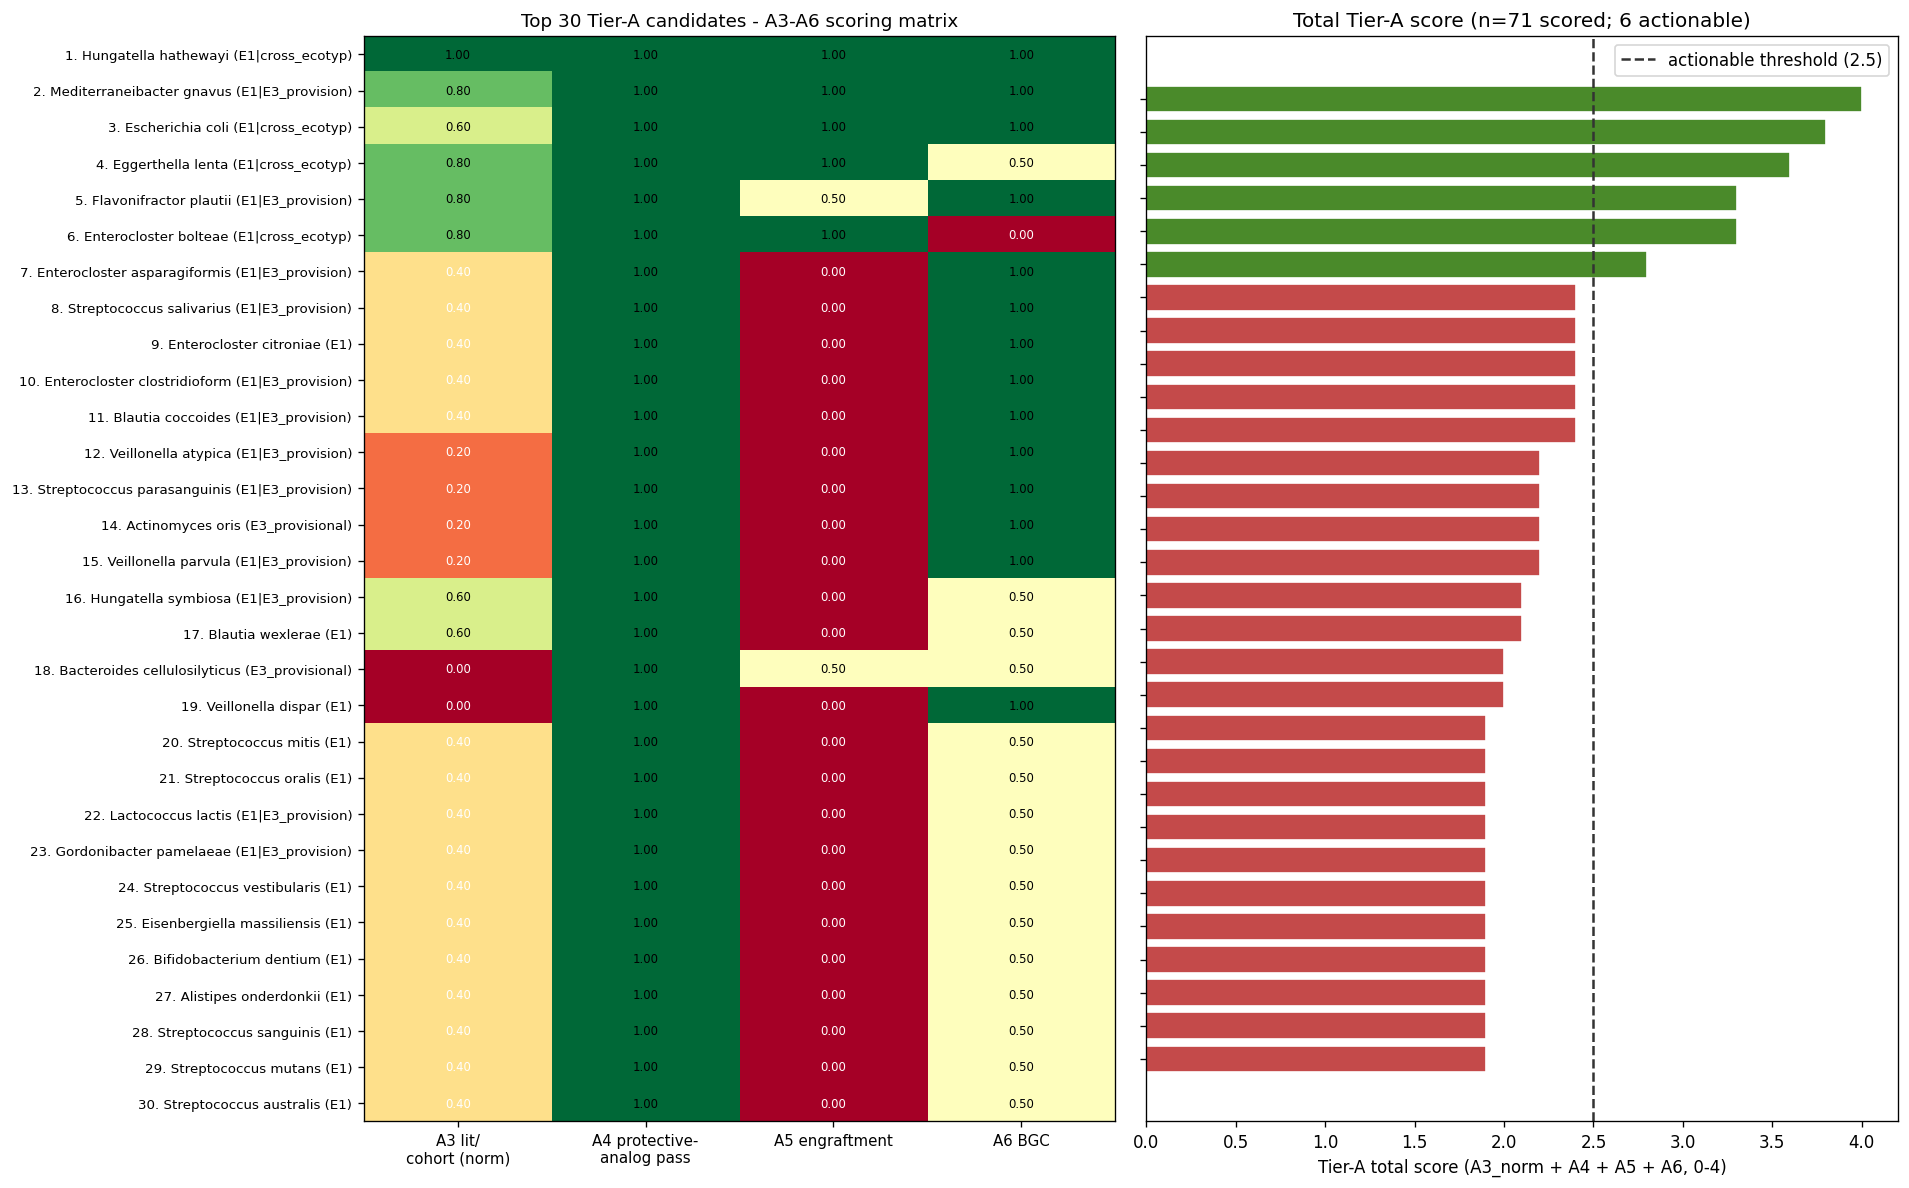

In [9]:
# Scoring matrix heatmap (top 30) + total-score bar chart.
# Generated by run_nb05.py; saved to figures/NB05_tier_a_scored.png.

## §9. Summary

The scored Tier-A list in `data/nb05_tier_a_scored.tsv` is the final prioritized target set for Pillar 4 (phage targetability) and Pillar 5 (UC Davis per-patient cocktail drafts).

**Top 6 actionable candidates (total_score ≥ 2.5, out of 71 scored)**:

| Rank | Species | Ecotype membership | A3 | A4 | A5 | A6 | Total | Notes |
|---:|---|---|---:|---:|---:|---:|---:|---|
| 1 | *Hungatella hathewayi* | E1 \| engraftment | 5 | 1 | 1.0 | 1.0 | **4.0** | all five A3 signals pass |
| 2 | *Mediterraneibacter gnavus* | E1 \| E3_prov \| engraftment | 4 | 1 | 1.0 | 1.0 | **3.8** | 39 BGCs, 26 CD-enriched CB-ORFs |
| 3 | *Escherichia coli* | E1 \| engraftment | 3 | 1 | 1.0 | 1.0 | **3.6** | MIBiG: Colibactin, Yersiniabactin, Enterobactin |
| 4 | *Eggerthella lenta* | E1 \| engraftment | 4 | 1 | 1.0 | 0.5 | **3.3** | engrafts + wide IBD literature |
| 5 | *Flavonifractor plautii* | E1 \| E3_prov | 4 | 1 | 0.5 | 1.0 | **3.3** | Kumbhari strain-competition + BGC |
| 6 | *Enterocloster bolteae* | E1 \| engraftment | 4 | 1 | 1.0 | 0.0 | **2.8** | engrafts; no BGC hit |

**Tier-B candidates (score 2.2–2.4, actionable with strain-level or A5 boost)**: *Enterocloster asparagiformis*, *Streptococcus salivarius* (Salivaricin 9/A / Cochonodin I MIBiG matches), *E. citroniae*, *E. clostridioformis*, *Blautia coccoides*, *Veillonella atypica*, *S. parasanguinis*, *Actinomyces oris*, *V. parvula*.

**Candidates failing A4 (protective-analog risk)**: *Anaerostipes hadrus* (confound-free effect −0.32), *Clostridium scindens* (curated protective list), *Roseburia faecis* (confound-free effect −2.74). These are flagged for strain-level scrutiny before any phage targeting — species-level call alone is insufficient to distinguish pathobiont from protective in these cases.

**Caveats** (see REPORT.md §5f for full discussion):
- E3 provisional candidates carry single-study (HallAB_2017) evidence within cMD.
- Cross-ecotype engraftment pathobionts are cohort-level; for ecotype-specific dosing, use the ecotype_membership annotation.
- The A3 `phage_biology_curated` signal catches only 3/71 candidates (curated list is small); most A3 score comes from cross-cohort concordance.
